This Jupyter Notebook follows chapter 2 of 'dynamical systems in neuroscience by izhikevich',
and aims to model and simulate neuron dynamics using giant squid axon parameters. Reading the chapter is recommended for understanding what each variable or parameter physically represents in the neuron. This Jupyter Notebook will only demonstrate a python implementation of the equations/model in the book. 

I will not not venture to explain the relevant theory behind each equation.

below is the guiding equation we will use to simulate neuron membrane potential dynamics. We are most interested in V, the neuron membrane potential, which evolves based on dV/dt in the equation.

We will build up the components of this equation and then analyse the neuron dynamics.

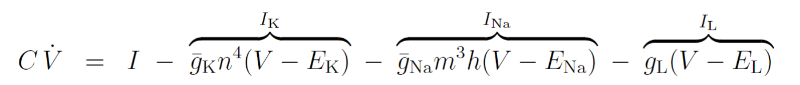


Calculate the nernst potentials using equation 2.1 and giant-squid-axon data given in exercise 1 of ch.2

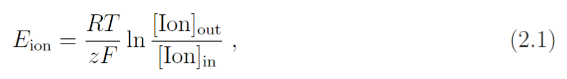
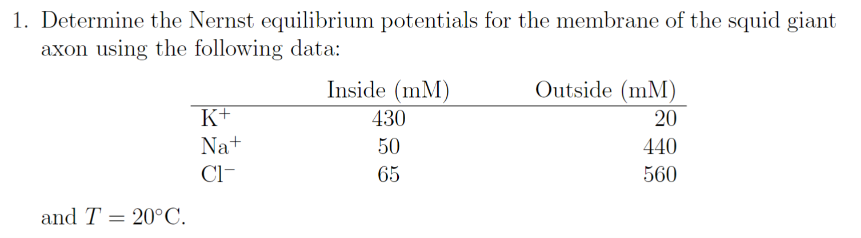


In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import plotly.io as pio
pio.renderers.default = "iframe"


# constants
T=20+273.15 #Kelvin
Capa = 1 #mF/cm^2 
gKmax = 36 #mS/cm^2
gNamax = 120 #mS/cm^2
gL = 0.3 #mS/cm^2

# nernst equilibrium potential equation
def nernst_full(T,z,IonIn,IonOut): # K,,Mol,Mol
    R=8315 #mJ/(K*Mol)
    F=96480 #C/Mol
    E_ion=R*T/z/F*math.log(IonOut/IonIn) #mV
    return E_ion

EK = nernst_full(T,1,430,20)
ENa = nernst_full(T,1,50,440)
ECl = nernst_full(T,-1,65,560) #E_L in guiding equation. Voltage leak is mainly driven by Cl- ions

Build up the differential equations for our activation/inactivation gate parameters n, m, and h:

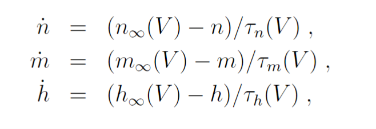

gate_inf(V) and tau(V) are calculated by gaussian (eq2.11) and boltzmann (eq2.12) equations respectively:

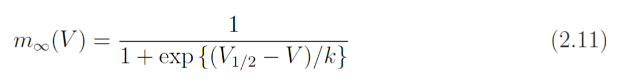
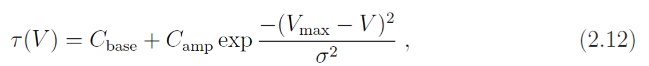


In [3]:
# gate parameters provided by book
gate_m = {
    "Vhalf":-40,
    "k":15/2,
    "Vmax":-38,
    "sigma":30,
    "Camp":0.46,
    "Cbase":0.04,
}
gate_h = {
    "Vhalf":-62,
    "k":-7,
    "Vmax":-67,
    "sigma":20,
    "Camp":7.4,
    "Cbase":1.2,
}
gate_n = {
    "Vhalf":-53,
    "k":15,
    "Vmax":-79,
    "sigma":50,
    "Camp":4.7,
    "Cbase":1.1,
}

#eq(2.11) Boltzmann equation
def gate_inf(V,gate):
    return  1/(1+np.exp((gate["Vhalf"]-V)/gate["k"])) 

#eq(2.12) gaussian
def timeconstant(V,gate):
    return gate["Cbase"] + gate["Camp"]*np.exp((-(gate["Vmax"]-V)**2)/gate["sigma"]**2) 

#eq(2.9) differential equation for [gate] activation dn/dt
def gate_diff(V,gate_id,gate_0):
    return (gate_inf(V,gate_id)-gate_0)/timeconstant(V,gate_id) 

Validate our boltzmann and guassian equations to Figure 2.13 in the book by plotting them.

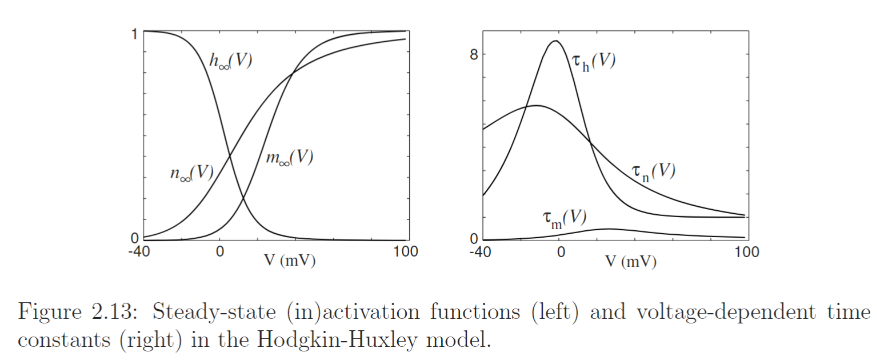

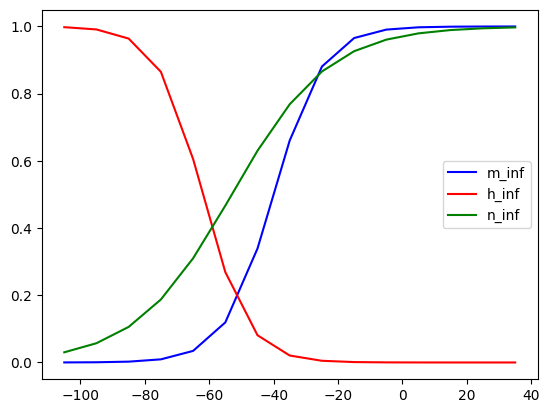

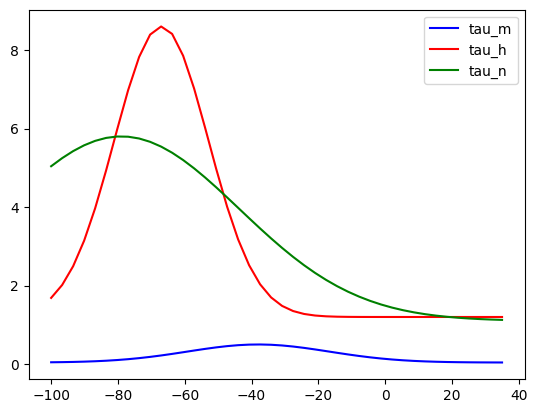

In [4]:
Vbolt = np.linspace(-40-65,35,15)
Vgauss = np.linspace(-100,35,14*3)

plt.figure()
plt.plot(Vbolt,gate_inf(Vbolt,gate_m), label="m_inf", color="blue")
plt.plot(Vbolt,gate_inf(Vbolt,gate_h), label="h_inf", color="red")
plt.plot(Vbolt,gate_inf(Vbolt,gate_n), label="n_inf", color="green")
plt.legend()

plt.figure()
plt.plot(Vgauss,timeconstant(Vgauss,gate_m), label="tau_m", color="blue")
plt.plot(Vgauss,timeconstant(Vgauss,gate_h), label="tau_h", color="red")
plt.plot(Vgauss,timeconstant(Vgauss,gate_n), label="tau_n", color="green")
plt.legend()

plt.show()

Upon viewing the plots, notice how our boltzmann curves of the gate_inf(V) parameters do not match exactly what we see in Figure 2.13. We expect m(V) to intersect n(V).

Try changing gate_m["k"] from 15 to 15/2 and plot again.

(note: Figure 2.13 has shifted the volt axis so that 0mV is the resting potential as Hogkin and Huxley did. We wont be shifting the voltage.)

We now have everything in our guiding equation.

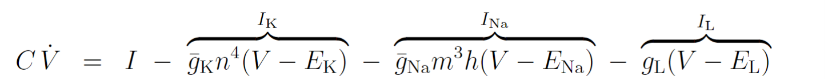

Let's setup the timeseries arrays to iteratively calculate this equation in a for-loop 

In [5]:
dt = 1/100 #ms time step
duration = 20 #ms 

# initializing arrays
t = np.arange(0,duration+1,dt)
range = len(t)+1 #+1 accounts for i+1 operation within for loop
V = np.zeros(range)
m = np.zeros(range)
h = np.zeros(range)
n = np.zeros(range)
I_K = np.zeros(range)
I_Na = np.zeros(range)
I_L = np.zeros(range)
Iapplied = np.zeros(range)

The differential equations will calculate and update each timestep in these arrays.

But we first need to set our initial conditions at t=0ms

It makes sense for these initial conditions to reflect the neuron at rest, or at the equilibrium membrane potential.

For the giant squid axon experiment, the book provides -65 mV as the resting potential. However, we can actually derive this number ourselves. 

We can plot our guiding equation, which is simply the sum of calculated currents, over a range of potentials mV. The resting potential will be where sum(current) = 0

(note: the book provides equation 2.4 to directly calculate V_rest, however this assumes that the conductances (g) are constant)

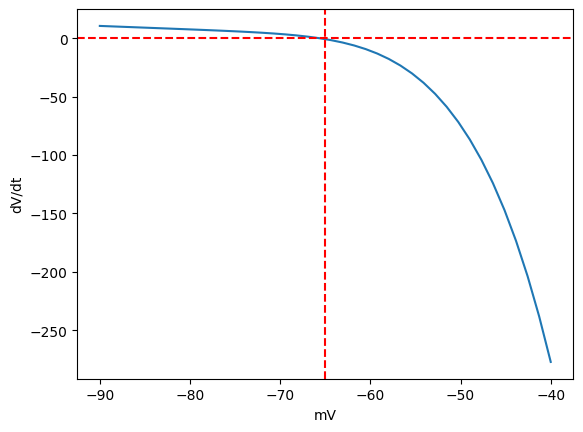

In [9]:
Varray = np.linspace(-40,-90,40)
Itest = np.zeros(len(Varray))
for i,Vstep in enumerate(Varray):
    Itest[i] = -(gKmax*(gate_inf(Vstep,gate_n)**4)*(Vstep-EK))-(gNamax*(gate_inf(Vstep,gate_m)**3)*(gate_inf(Vstep,gate_h))*(Vstep-ENa))-(gL*(Vstep-ECl))

plt.figure()
plt.plot(Varray,Itest, label="current flows")
plt.xlabel('mV')
plt.ylabel('dV/dt')
plt.axhline(y=0,color='r',linestyle='--')
plt.axvline(x=-65,color='r',linestyle='--')
plt.show()

We now know for certain the resting potential, given the neuron parameters we are using, is -65mV

(note: this largely doesnt matter because the dynamic system will come to its exact rest potential by itself in the simulation as we will see)

We can setup the initial conditions:

In [7]:
V_0 = -65.5

# intial values of iterated variables
V[0] = V_0
m[0] = m_0 = gate_inf(V_0,gate_m)
h[0] = h_0 = gate_inf(V_0,gate_h)
n[0] = n_0 = gate_inf(V_0,gate_n)

I_K[0]=gKmax*(n_0**4)*(V[0]-EK)
I_Na[0]=gNamax*(m_0**3)*h_0*(V[0]-ENa)
I_L[0]=gL*(V[0]-ECl)

Simulate the neuron using our guiding equation in an iterating loop.

Then plot the timeseries arrays.

*reminder: add a flowchart showing what this loop is doing. 

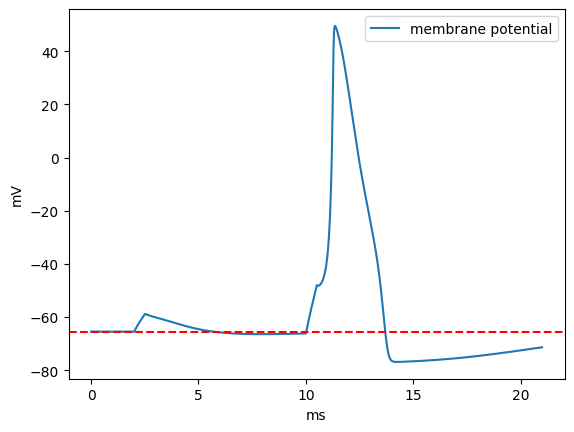

In [8]:
for i,time in enumerate(t):

    # programming applied current pulses
    if time>=2   and time<=2.5:
        Iapplied[i]=15
    elif time>=10 and time<=10.5:
        Iapplied[i]=40

    # guiding equation:
    dV = (Iapplied[i]-I_K[i]-I_Na[i]-I_L[i])/Capa*dt
    V[i+1] = V[i]+dV

    dm = gate_diff(V[i],gate_m,m[i])*dt
    dh = gate_diff(V[i],gate_h,h[i])*dt
    dn = gate_diff(V[i],gate_n,n[i])*dt

    m[i+1]=m[i]+dm
    h[i+1]=h[i]+dh
    n[i+1]=n[i]+dn

    I_K[i+1]=gKmax*(n[i+1]**4)*(V[i+1]-EK)
    I_Na[i+1]=gNamax*(m[i+1]**3)*h[i+1]*(V[i+1]-ENa)
    I_L[i+1]=gL*(V[i+1]-ECl)

plt.figure()
plt.plot(t,V[0:len(V)-1], label="membrane potential")
plt.xlabel("ms")
plt.ylabel("mV")
plt.legend()
plt.axhline(y=V_0,color='r',linestyle='--')
plt.show()


We have now demonstrated the dynamics of neuron membrane potential as depicted in Figure 2.15 of the book.